In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

import scipy.stats as stats

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error,median_absolute_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-price-prediction-challenge/car_price_prediction.csv


# Data Collection


In [2]:
data = pd.read_csv(r'/kaggle/input/car-price-prediction-challenge/car_price_prediction.csv')
data

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


# Data Cleaning & Preprocessing

In [3]:
data.head(3)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2


In [4]:
data.tail(3)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4
19236,45813273,470,753,HYUNDAI,Sonata,2012,Sedan,Yes,Hybrid,2.4,186923 km,4.0,Automatic,Front,04-May,Left wheel,White,12


In [5]:
print("The number of rows  is :",data.shape[0])
print("The number of columns is :",data.shape[1])

The number of rows  is : 19237
The number of columns is : 18


In [6]:
data.dtypes

ID                    int64
Price                 int64
Levy                 object
Manufacturer         object
Model                object
Prod. year            int64
Category             object
Leather interior     object
Fuel type            object
Engine volume        object
Mileage              object
Cylinders           float64
Gear box type        object
Drive wheels         object
Doors                object
Wheel                object
Color                object
Airbags               int64
dtype: object

In [7]:
#Check statistics of Dataset #Only for numeric features
data.describe() 

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

**Car Variety 🚗🚙**
The dataset includes 1,590 unique car models, showing a diverse range of vehicles.

**Price Range 💰**

* Median Price: €13,172 (50% of cars cost less than this).

* Mean Price: €18,556, which is higher than the median, suggesting right-skewed data (some very expensive cars are pulling the average up).

* Max Price: €26.3 million—this is an extreme outlier, likely a luxury or rare car.

* Min Price: €1—probably an entry error or a very old/damaged car.

**Insights from Statistics** 

Data Cleaning Needed: The €1 price and 26.3M price suggest possible errors or extreme outliers.

Market Trend: Most cars are from 2010+, meaning the dataset leans toward newer models.

Luxury vs. Economy: The high max values for price, cylinders, and airbags indicate that the dataset includes both budget and premium cars.

In [9]:
print(data.columns)

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')


In [10]:
# Checking for Missing values
data.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [11]:
data.isnull().sum().sum()

0

In [12]:
# Check the number of unique values of each column
data.nunique()

ID                  18924
Price                2315
Levy                  559
Manufacturer           65
Model                1590
Prod. year             54
Category               11
Leather interior        2
Fuel type               7
Engine volume         107
Mileage              7687
Cylinders              13
Gear box type           4
Drive wheels            3
Doors                   3
Wheel                   2
Color                  16
Airbags                17
dtype: int64

In [13]:
# Check for duplication
data.duplicated().sum()

313

In [14]:
# Remove all duplications
data.drop_duplicates(inplace = True)
data.shape[0]

18924

**The ID column do not carry any meaningful information to predict the target variable (car price), it does not help the model understand patterns in the data. So I will drop it.**

In [15]:
data.drop(columns=['ID'], axis=1, inplace=True)
data.head(7)


,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12


In [16]:
(data['Levy'] == '-').sum()

5709

**Feature transformation 🛠️**

*  5,819 rows in the **'Levy'** column contain the value '-'.

*  **Mileage:** is stored as a Object (e.g., "100,000 km"), so we need to convert it to an integer.

*  **Engine volume:** If it includes letters like "2.0 Turbo", we'll need to extract the numeric part.

*  **Doors:** is categorical and has inconsistent values (e.g., "04-May", '02-Mar', '>5'), we have to clean it up.


In [17]:
# Convert 'Cylinders' column from float64 to int64
data["Cylinders"] = data["Cylinders"].astype('int64')

####################################################################

#There are non-numeric values (like '-') in the 'Levy' column that cannot be directly converted to integers. 
#To handle this, I'll transform the column before converting it.

# Step 1: Replace '-' with NaN
data['Levy'] = pd.to_numeric(data['Levy'], errors='coerce')

# Step 2: Convert to int64 
data['Levy'] = data['Levy'].fillna(0).astype('int64')  # Replace NaN with 0 value

####################################################################

# Step 1: Replace 'Km' with ''
data['Mileage'] = pd.to_numeric(data['Mileage'].replace(r'\s*km', '', regex=True))

# Step 2:Convert Mileage to int64 
data["Mileage"] = data["Mileage"].astype('int64')

###################################################################

# 'Engine volume' column contains values like '2.2 Turbo', where "2.2" is a float and "Turbo" is a string.
#I need first to extract the numeric part then convert it into float64

data["Engine volume"].unique() 

#  Step 1: Replace 'Turbo' with  empty string (or NaN)
data['Engine volume'] = pd.to_numeric(data['Engine volume'].replace(r'\s*Turbo', '', regex=True))

#  Step 2: Convert the column to numeric, errors='coerce' will handle any other non-numeric values and convert them to NaN
data['Engine volume'] = pd.to_numeric(data['Engine volume'], errors='coerce')

#  Step 3: fill NaN with 0 
data['Engine volume'] = data['Engine volume'].fillna(0)

# Convert to float64
data['Engine volume'] = data['Engine volume'].astype('float64')

######################################################################

# Replace Doors with numeric values

data['Doors'].replace({'04-May': 4, '02-Mar': 2, '>5': 5}, inplace=True)

# Print the Result 

print(data["Cylinders"])
print()
print(data['Levy'])
print(data['Engine volume'])
print(data['Mileage'])
print(data['Doors'])

0        6
1        6
2        4
3        4
4        4
        ..
19232    4
19233    4
19234    4
19235    4
19236    4
Name: Cylinders, Length: 18924, dtype: int64

0        1399
1        1018
2           0
3         862
4         446
         ... 
19232       0
19233     831
19234     836
19235    1288
19236     753
Name: Levy, Length: 18924, dtype: int64
0        3.5
1        3.0
2        1.3
3        2.5
4        1.3
        ... 
19232    2.0
19233    2.4
19234    2.0
19235    2.0
19236    2.4
Name: Engine volume, Length: 18924, dtype: float64
0        186005
1        192000
2        200000
3        168966
4         91901
          ...  
19232    300000
19233    161600
19234    116365
19235     51258
19236    186923
Name: Mileage, Length: 18924, dtype: int64
0        4
1        4
2        4
3        4
4        4
        ..
19232    2
19233    4
19234    4
19235    4
19236    4
Name: Doors, Length: 18924, dtype: int64


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  int64  
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  float64
 9   Mileage           18924 non-null  int64  
 10  Cylinders         18924 non-null  int64  
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  int64  
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

I will detects outliers using the IQR method, optionally I will replace them with the median, and visualizes them using box plots.


Replacing outliers in column: Price


Outliers in 'Price' before replacement:
14    59464
36    51746
47    55390
56    87112
73    53154
Name: Price, dtype: int64


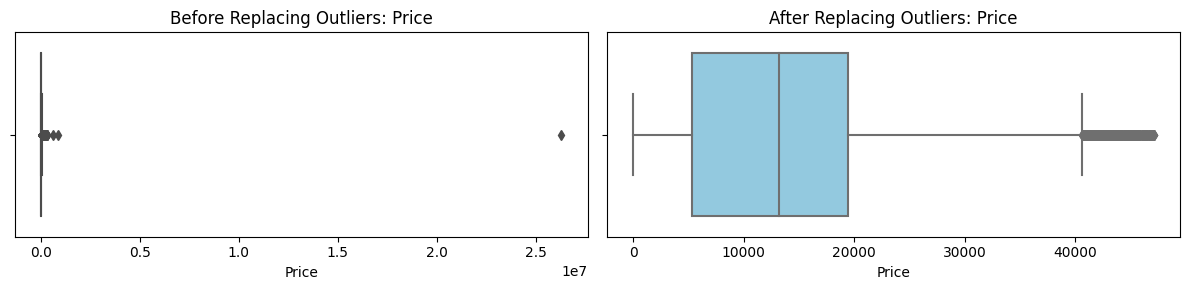

Outliers replaced in Price:
14       13172
36       13172
47       13172
56       13172
73       13172
         ...  
19144    13172
19161    13172
19180    13172
19188    13172
19211    13172
Name: Price, Length: 1055, dtype: int64

Replacing outliers in column: Levy


Outliers in 'Levy' before replacement:
18      2386
26      2455
78      2455
115    11714
132     2866
Name: Levy, dtype: int64


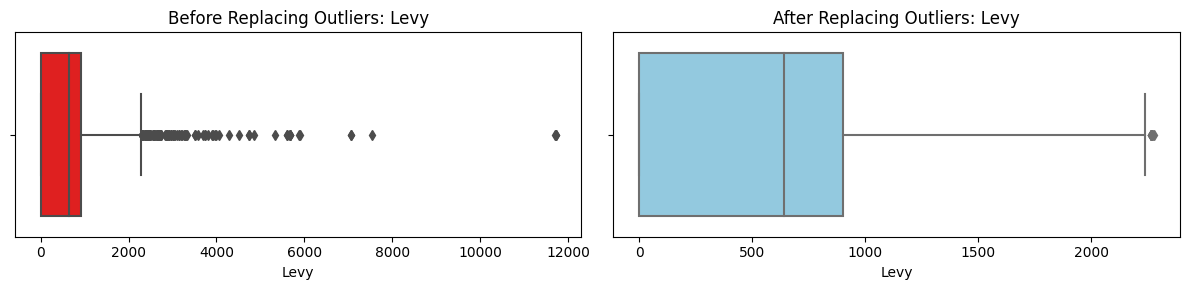

Outliers replaced in Levy:
18       642
26       642
78       642
115      642
132      642
        ... 
18854    642
18957    642
18963    642
18984    642
19048    642
Name: Levy, Length: 160, dtype: int64

Replacing outliers in column: Engine volume


Outliers in 'Engine volume' before replacement:
11    4.0
26    4.7
32    4.4
44    3.6
45    4.0
Name: Engine volume, dtype: float64


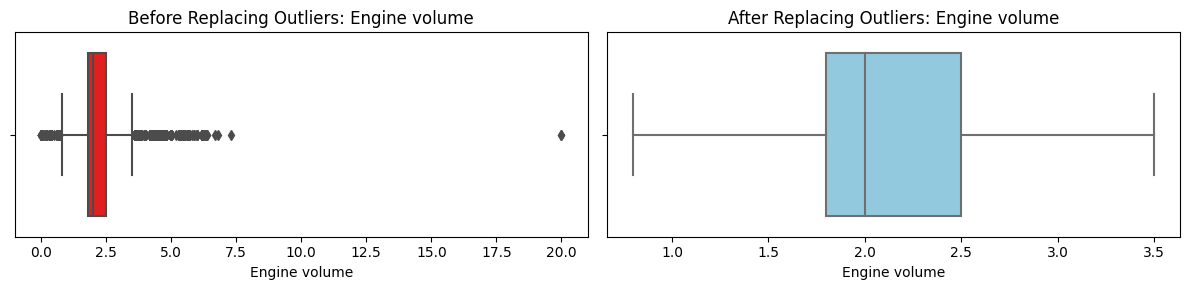

Outliers replaced in Engine volume:
11       2.0
26       2.0
32       2.0
44       2.0
45       2.0
        ... 
19038    2.0
19045    2.0
19048    2.0
19058    2.0
19186    2.0
Name: Engine volume, Length: 1358, dtype: float64

Replacing outliers in column: Mileage


Outliers in 'Mileage' before replacement:
8     398069
29    420550
39    382746
65    719847
90    433811
Name: Mileage, dtype: int64


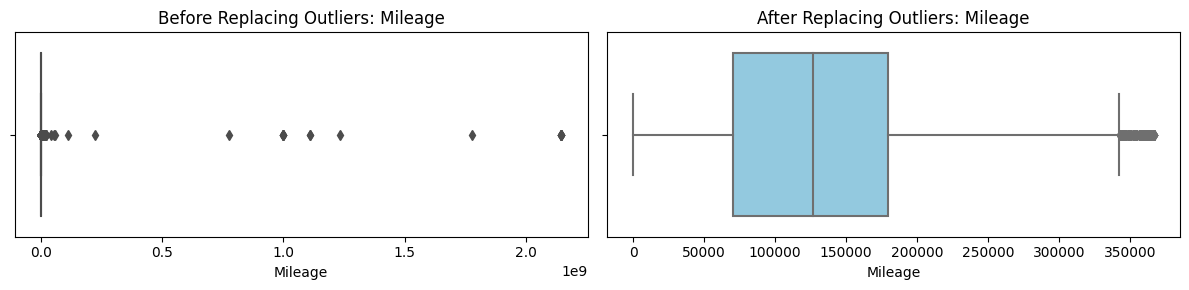

Outliers replaced in Mileage:
8        126400
29       126400
39       126400
65       126400
90       126400
          ...  
19163    126400
19167    126400
19194    126400
19199    126400
19222    126400
Name: Mileage, Length: 635, dtype: int64

Replacing outliers in column: Cylinders


Outliers in 'Cylinders' before replacement:
0     6
1     6
9     6
10    6
11    8
Name: Cylinders, dtype: int64


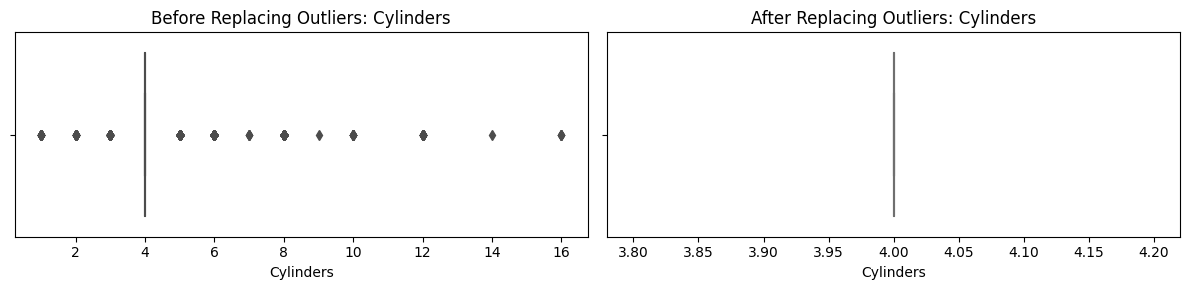

Outliers replaced in Cylinders:
0        4
1        4
9        4
10       4
11       4
        ..
19221    4
19226    4
19227    4
19228    4
19231    4
Name: Cylinders, Length: 4765, dtype: int64

Replacing outliers in column: Airbags


Outliers in 'Airbags' before replacement:
Series([], Name: Airbags, dtype: int64)


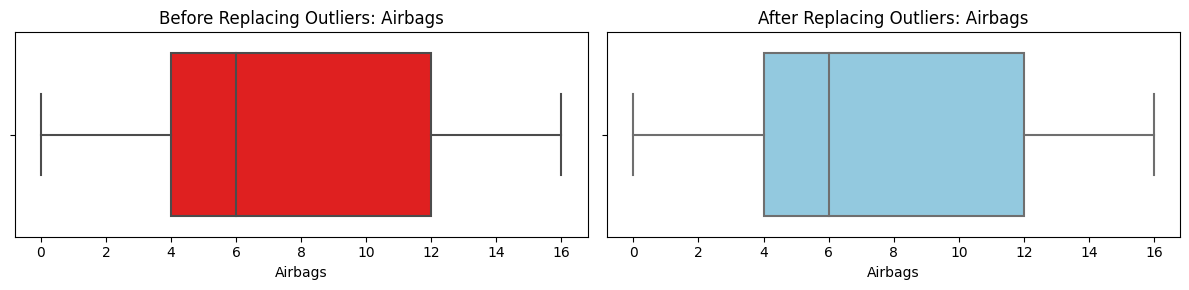

Outliers replaced in Airbags:
Series([], Name: Airbags, dtype: int64)

Replacing outliers in column: Doors


Outliers in 'Doors' before replacement:
11    2
23    2
55    2
75    2
95    2
Name: Doors, dtype: int64


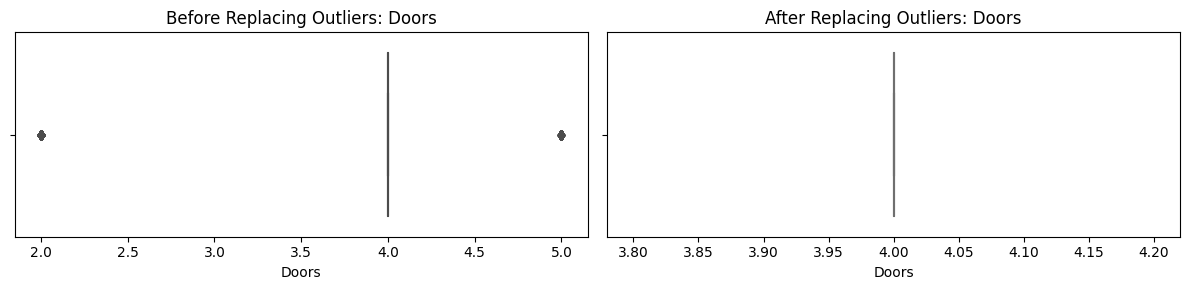

Outliers replaced in Doors:
11       4
23       4
55       4
75       4
95       4
        ..
19115    4
19118    4
19167    4
19169    4
19232    4
Name: Doors, Length: 892, dtype: int64

Final DataFrame after outlier replacement:
   Price  Levy  Engine volume  Mileage  Cylinders  Airbags  Doors
0  13328  1399            3.5   186005          4       12      4
1  16621  1018            3.0   192000          4        8      4
2   8467     0            1.3   200000          4        2      4
3   3607   862            2.5   168966          4        0      4
4  11726   446            1.3    91901          4        4      4


In [19]:
# Selecting relevant columns for outlier detection
data_check = data[['Price','Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags','Doors']].copy()

# Function to replace outliers in a column with the median
def replace_outliers_with_median(dataframe, col):
    if col not in dataframe.columns:
        raise KeyError(f"Column '{col}' not found in the DataFrame.")

    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)

# Print the original outlier values before replacing them
    print(f"\nOutliers in '{col}' before replacement:")
    print(dataframe.loc[outliers, col].head(5))  # Display first 5 outliers

 # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))  # 1 row, 2 columns
    
# Plot before replacement
    sns.boxplot(x=dataframe[col], ax=axes[0], color='red')
    axes[0].set_title(f"Before Replacing Outliers: {col}")
    

# Replace outliers with the median
    median_value = dataframe[col].median()
    dataframe.loc[outliers, col] = median_value

 # Plot after replacement
    sns.boxplot(x=dataframe[col], ax=axes[1], color='skyblue')
    axes[1].set_title(f"After Replacing Outliers: {col}")

    plt.tight_layout()
    plt.show() 
    
    return outliers  # Return mask of outliers

# Apply function to each column
for col in ['Price','Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags','Doors']:
    print(f"\n\033[1mReplacing outliers in column: {col}\033[0m")  # Bold text
    print() 
    outliers = replace_outliers_with_median(data_check, col)

    print(f"Outliers replaced in {col}:")
   
    print(data_check.loc[outliers, col])  # Show replaced values

# ✅ Display the modified DataFrame
print("\nFinal DataFrame after outlier replacement:")
print(data_check.head())

# Visualisation & Analysis

In [20]:
for i in data.columns: 
    print(i, ":", data[i].nunique())  # Number of unique 

Price : 2315
Levy : 559
Manufacturer : 65
Model : 1590
Prod. year : 54
Category : 11
Leather interior : 2
Fuel type : 7
Engine volume : 65
Mileage : 7687
Cylinders : 13
Gear box type : 4
Drive wheels : 3
Doors : 3
Wheel : 2
Color : 16
Airbags : 17


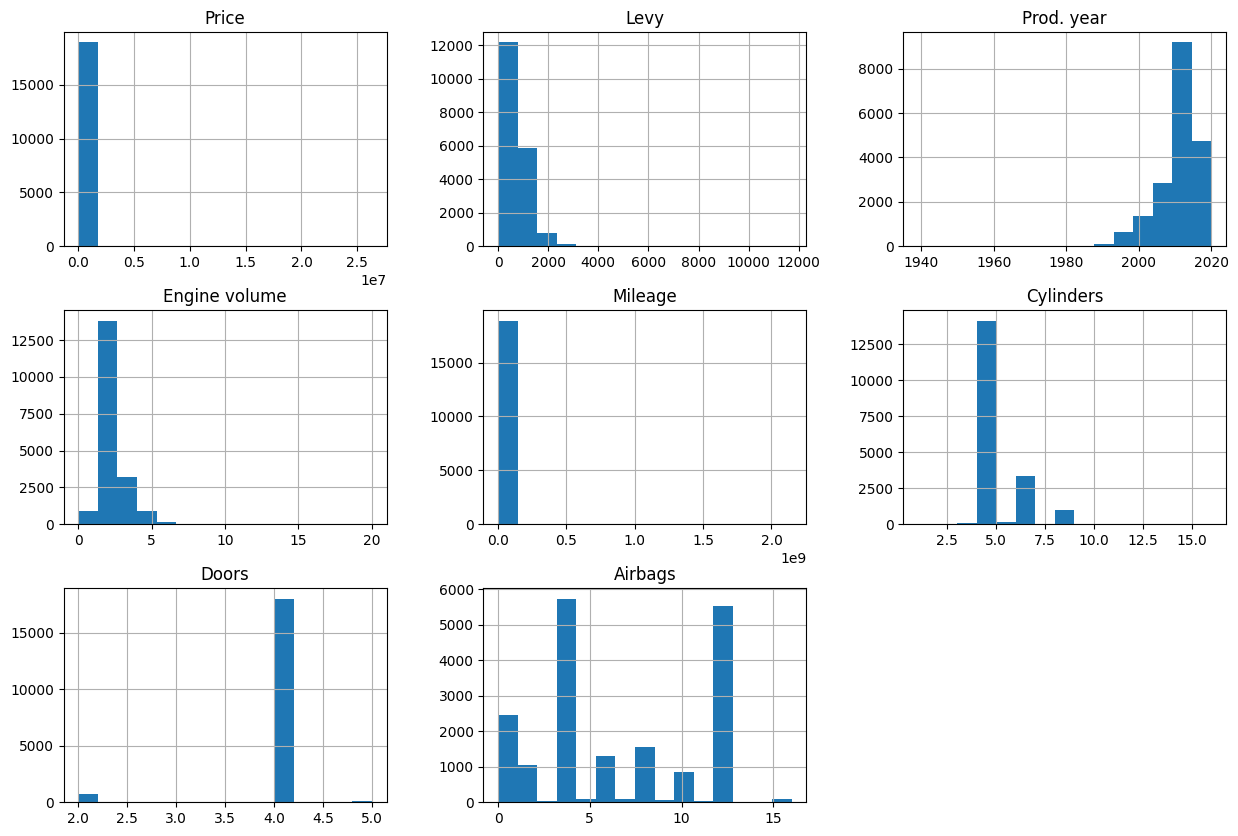

In [21]:
data.hist(bins= 15, figsize =(15,10))
plt.show() 


In [22]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation
correlation_matrix = numeric_data.corr()

# Display result
correlation_matrix

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Doors,Airbags
Price,1.000000,-0.003558,0.012689,0.008888,-0.001763,0.007435,-0.033387,-0.012709
Levy,-0.003558,1.000000,0.362827,0.378117,-0.021203,0.251632,0.096430,0.125015
Prod. year,0.012689,0.362827,1.000000,-0.032427,-0.064058,-0.099443,0.195710,0.235160
Engine volume,0.008888,0.378117,-0.032427,1.000000,-0.006292,0.777228,-0.017697,0.221991
Mileage,-0.001763,-0.021203,-0.064058,-0.006292,1.000000,-0.001720,-0.006287,-0.009174
Cylinders,0.007435,0.251632,-0.099443,0.777228,-0.001720,1.000000,-0.036033,0.174112
Doors,-0.033387,0.096430,0.195710,-0.017697,-0.006287,-0.036033,1.000000,0.048088
Airbags,-0.012709,0.125015,0.235160,0.221991,-0.009174,0.174112,0.048088,1.000000


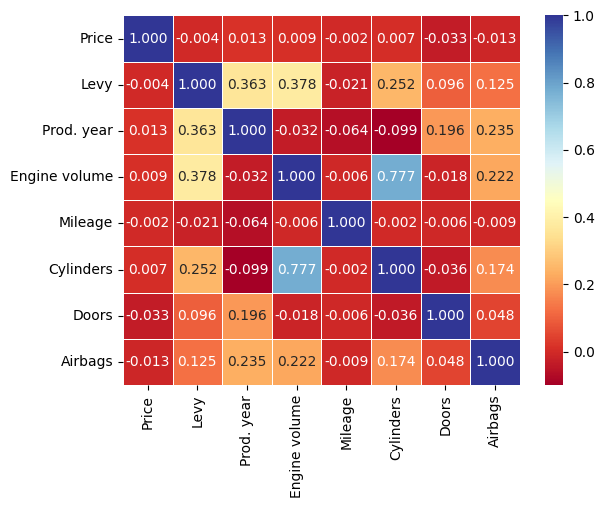

In [23]:
sns.heatmap(correlation_matrix , annot =True ,linewidths= 0.5, cmap= 'RdYlBu', fmt= '.3f' )
plt.show()

**Strong Positive Correlations:**

✅ Engine volume vs. Cylinders: 0.777: Larger engines tend to have more cylinders.

✅ Levy vs. Engine volume: 0.378: Higher taxes (levy) may be associated with larger engines.

✅ Prod. year vs. Airbags: 0.235: Newer cars tend to have more airbags.

❌ Price vs. Most Variables: Coefficients close to 0 (e.g., -0.004 with Levy, 0.013 with Prod. year).

❌ Price shows almost no linear relationship with the listed numerical variables in this dataset.

In [24]:
data["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'სხვა', 'HAVAL', 'HUMMER', 'SCION',
       'UAZ', 'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [25]:
# Find the top 10 manufacturers by count
top10_manufacturers = data["Manufacturer"].value_counts().sort_values(ascending = False)[:10]
top10_manufacturers

Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
BMW              1036
HONDA             960
LEXUS             927
NISSAN            645
VOLKSWAGEN        571
Name: count, dtype: int64

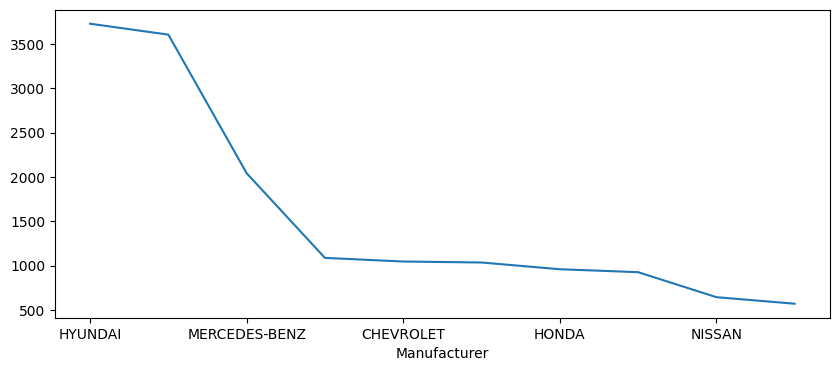

In [26]:
top10_manufacturers.plot(figsize= (10,4))
plt.show()

In [27]:
top10_price = data.nlargest(10, "Price")  # Get top 10 most expensive cars
top10_price 

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
16983,26307500,0,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999,4,Manual,Front,2,Left wheel,Blue,0
8541,872946,2067,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4.0,2531,8,Tiptronic,4x4,4,Left wheel,Black,0
1225,627220,0,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3,0,8,Tiptronic,4x4,4,Left wheel,Black,12
5008,308906,1694,PORSCHE,911,2016,Coupe,Yes,Petrol,4.0,8690,6,Automatic,Rear,2,Left wheel,Black,12
9367,297930,0,MERCEDES-BENZ,AMG GT S,2015,Coupe,Yes,Petrol,4.0,20000,8,Tiptronic,Rear,2,Left wheel,White,16
14839,297930,0,LAND ROVER,Range Rover Vogue,2019,Jeep,Yes,Diesel,3.0,4500,8,Tiptronic,4x4,4,Left wheel,Black,12
7749,288521,2269,BMW,M5 Машина в максимально,2018,Sedan,Yes,Petrol,4.4,13500,8,Tiptronic,4x4,4,Left wheel,Black,0
10759,260296,0,LEXUS,LX 570,2018,Jeep,Yes,Petrol,5.7,17700,8,Tiptronic,4x4,4,Left wheel,Black,10
5840,254024,1292,MERCEDES-BENZ,GLE 400 A M G,2016,Jeep,Yes,Petrol,3.0,73000,6,Tiptronic,4x4,4,Left wheel,Black,12
15283,250574,1481,MERCEDES-BENZ,GLE 400,2017,Jeep,Yes,Petrol,3.0,81600,6,Tiptronic,4x4,4,Left wheel,Black,12


In [28]:
top10_manufacturers = data["Manufacturer"].value_counts().head(10).index

# Filter data to include only these manufacturers
filtered_data = data[data["Manufacturer"].isin(top10_manufacturers)]

# Calculate mean price for each manufacturer
mean_prices = filtered_data.groupby("Manufacturer")["Price"].mean().sort_values(ascending= False)

print("Mean price of cars for the top 10 manufacturers:\n", mean_prices)

Mean price of cars for the top 10 manufacturers:
 Manufacturer
HYUNDAI          22306.000805
BMW              20609.468147
LEXUS            20052.594391
MERCEDES-BENZ    18590.331375
FORD             15411.850184
CHEVROLET        14894.873926
TOYOTA           14302.447865
HONDA            14162.073958
VOLKSWAGEN       11471.774081
NISSAN            9835.840310
Name: Price, dtype: float64


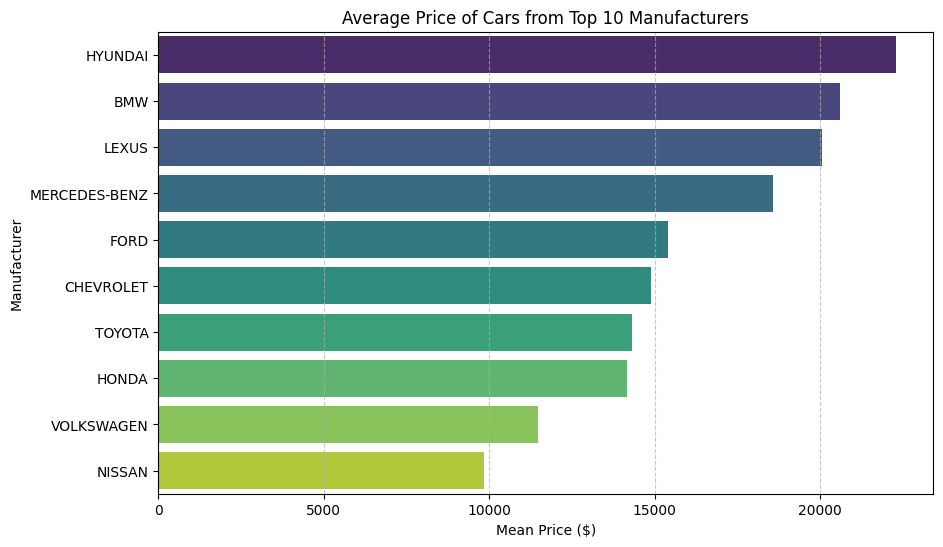

In [29]:
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_prices.values, y=mean_prices.index, palette="viridis")

# Labels and title
plt.xlabel("Mean Price ($)")
plt.ylabel("Manufacturer")
plt.title("Average Price of Cars from Top 10 Manufacturers")
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Show plot
plt.show()

In [30]:
# Ensure column names are clean
data.columns = data.columns.str.strip()

# Check if 'Prod. year' exists in the DataFrame before proceeding
if 'Prod. year' in data.columns:
    # Convert to numeric, handle errors, and drop missing values
    data['Prod. year'] = pd.to_numeric(data['Prod. year'], errors='coerce')
    data = data.dropna(subset=['Prod. year', 'Price'])

    # Ensure 'Prod. year' is an integer
    data['Prod. year'] = data['Prod. year'].astype(int)

    # Check min and max year before processing
    print("Min year:", data['Prod. year'].min(), "Max year:", data['Prod. year'].max())

    # Group by production year and calculate the average price
    avg_price_by_year = data.groupby('Prod. year', as_index=False)['Price'].mean()

    # Sort by production year
    avg_price_by_year = avg_price_by_year.sort_values('Prod. year')

    # Print first 15 rows to check if all years exist
    print(avg_price_by_year.head(15))

    # Create a line plot
    fig = px.line(avg_price_by_year, x='Prod. year', y='Price', 
                  markers=True, 
                  title='Average Car Price by Year',
                  labels={'Prod. year': 'Production Year', 'Price': 'Average Price (€)'})

    # Increase figure size
    fig.update_layout(width=1300, height=700)

    # Add hover functionality
    fig.update_traces(hoverinfo="x+y", mode="lines+markers")

    # Show plot
    fig.show()
else:
    print("❌ Error: Column 'Prod. year' not found in the dataset!")
    print("Available columns:", data.columns)


Min year: 1939 Max year: 2020
    Prod. year          Price
0         1939     171.333333
1         1943  119172.000000
2         1947     150.000000
3         1953   17735.250000
4         1957    7527.000000
5         1964    6585.500000
6         1965   65074.000000
7         1968    2200.000000
8         1973   15681.000000
9         1974    2437.000000
10        1976     400.000000
11        1977   10340.500000
12        1978    1400.000000
13        1980    1925.000000
14        1981    2800.000000


In [31]:
# Find the year with the smallest and largest average prices
min_price_index = avg_price_by_year['Price'].idxmin()
max_price_index = avg_price_by_year['Price'].idxmax()

min_price_row = avg_price_by_year.loc[min_price_index, ['Prod. year', 'Price']]
max_price_row = avg_price_by_year.loc[max_price_index, ['Prod. year', 'Price']]

# Convert the year to integer (no decimal places)
min_year = int(min_price_row['Prod. year'])
max_year = int(max_price_row['Prod. year'])

# Print results with the year as an integer
print(f"Smallest Average Price: {min_price_row['Price']:.2f} in Year {min_year}")
print(f"Largest Average Price: {max_price_row['Price']:.2f} in Year {max_year}")

Smallest Average Price: 150.00 in Year 1947
Largest Average Price: 135935.49 in Year 1999


In [32]:
category_counts = data['Category'].value_counts().reset_index()

category_counts.columns = ['Category', 'Count']

print(category_counts)

# Plot the distribution using Plotly
fig = px.bar(category_counts, x='Category', y='Count', 
             title='Frequency Distribution of Car Categories', 
             labels={'Category': 'Car Category', 'Count': 'Count'},
             color='Category', # Optional: To color the bars differently
             hover_data={'Count': True})  # Show count on hover

# Update figure layout
fig.update_layout(width=800, height=600)

# Show the plot
fig.show()

       Category  Count
0         Sedan   8600
1          Jeep   5378
2     Hatchback   2799
3       Minivan    633
4         Coupe    528
5     Universal    361
6      Microbus    299
7   Goods wagon    229
8        Pickup     51
9     Cabriolet     35
10    Limousine     11


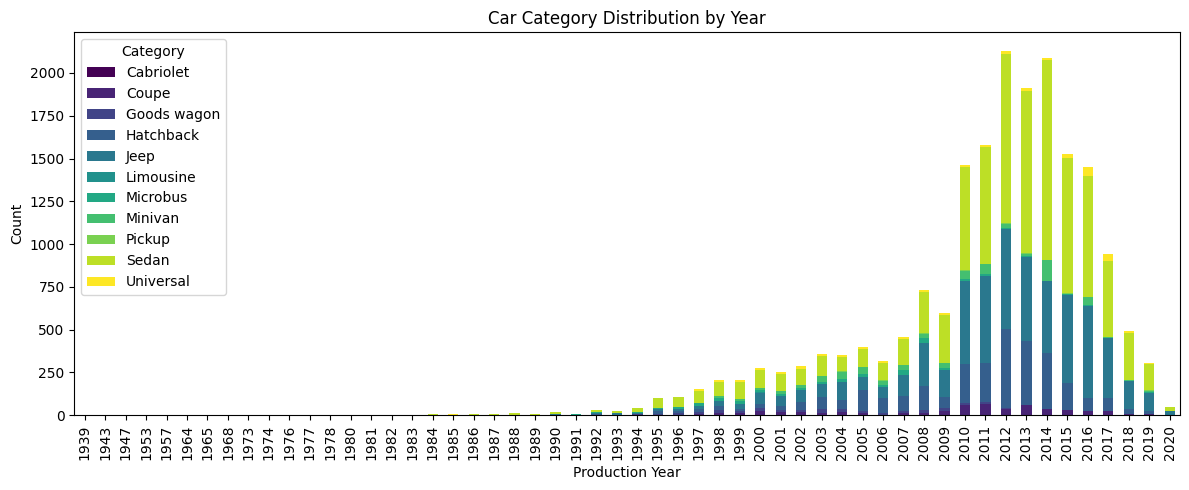

In [33]:
# stacked bar plot (for example, comparing 'Car Category' over 'Prod_year')
category_by_year = data.groupby(['Prod. year', 'Category']).size().unstack(fill_value=0)

# Plot a stacked bar chart
category_by_year.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='viridis')

# Set labels and title
plt.title('Car Category Distribution by Year')
plt.ylabel('Count')
plt.xlabel('Production Year')
plt.tight_layout()

plt.show()

**Frequency Distribution of Car Model**

In [34]:
print("Car Model Frequency Distribution:")
print(data['Model'].value_counts())
print("\n")

Car Model Frequency Distribution:
Model
Prius                     1069
Sonata                    1067
Camry                      929
Elantra                    910
E 350                      534
                          ... 
1500,1600 Schtufenheck       1
E 420                        1
C 250 luxury                 1
Passat sport                 1
Prius C aqua                 1
Name: count, Length: 1590, dtype: int64




**Frequency Distribution of Leather Interior**

Leather Interior Frequency Distribution:
Leather interior
Yes    13731
No      5193
Name: count, dtype: int64




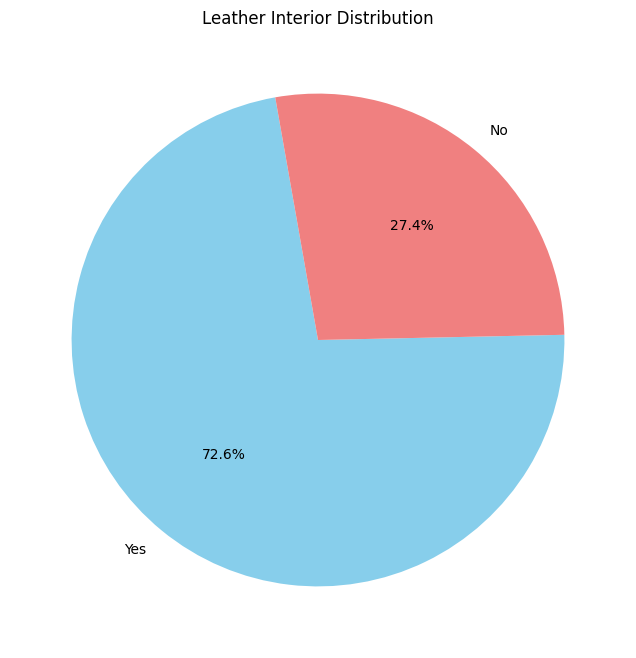

In [35]:
# Print the frequency distribution
print("\033[1mLeather Interior Frequency Distribution:\033[0m")
leather_counts = data['Leather interior'].value_counts()
print(leather_counts)
print("\n")

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(leather_counts, labels=leather_counts.index, autopct='%1.1f%%', 
        colors=['skyblue', 'lightcoral'], startangle=100)

# Add title
plt.title("Leather Interior Distribution")

# Show the plot
plt.show()

**Frequency Distribution of Fuel Type**

In [36]:
data['Fuel type'].unique()

array(['Hybrid', 'Petrol', 'Diesel', 'CNG', 'Plug-in Hybrid', 'LPG',
       'Hydrogen'], dtype=object)

In [37]:
print("Fuel Type Frequency Distribution:")
print(data['Fuel type'].value_counts())
print("\n")

Fuel Type Frequency Distribution:
Fuel type
Petrol            9944
Diesel            4001
Hybrid            3539
LPG                885
CNG                469
Plug-in Hybrid      85
Hydrogen             1
Name: count, dtype: int64




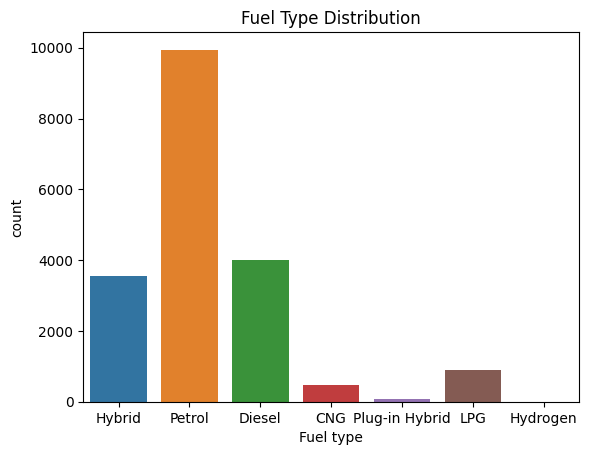

In [38]:
# Plotting the frequency distribution for 'Fuel type'
sns.countplot(data=data, x='Fuel type')
plt.title("Fuel Type Distribution")
plt.show()

**Frequency Distribution of Gear box type**

Gearbox Type Frequency Distribution:
Gear box type
Automatic    13282
Tiptronic     3065
Manual        1844
Variator       733
Name: count, dtype: int64




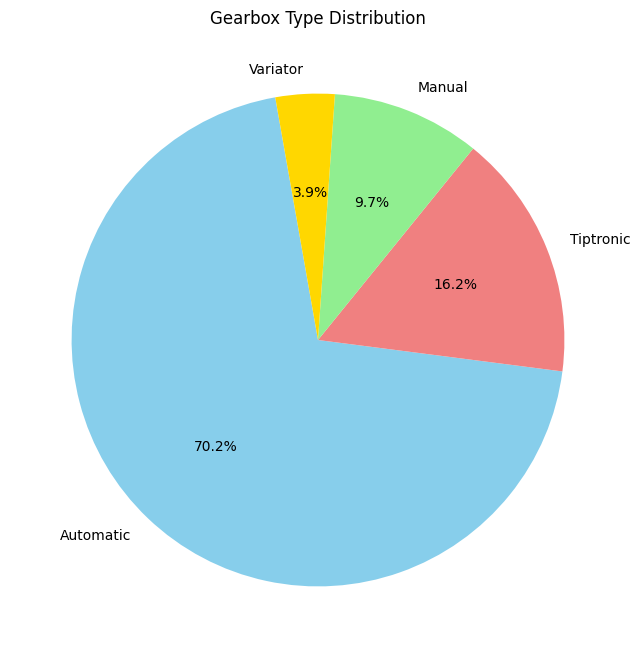

In [39]:
# Print the frequency distribution
print("Gearbox Type Frequency Distribution:")
gearbox_counts = data['Gear box type'].value_counts()
print(gearbox_counts)
print("\n")

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(gearbox_counts, labels=gearbox_counts.index, autopct='%1.1f%%', 
        colors=['skyblue', 'lightcoral', 'lightgreen', 'gold'], startangle=100)

# Add title
plt.title("Gearbox Type Distribution")

# Show the plot
plt.show()

**Frequency Distribution of Drive wheels**

Drive Wheels Frequency Distribution:
Drive wheels
Front    12695
4x4       3969
Rear      2260
Name: count, dtype: int64




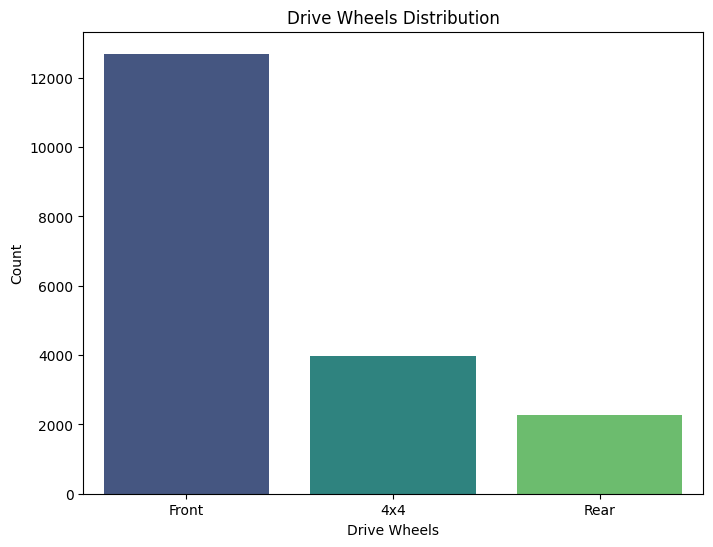

In [40]:
print("Drive Wheels Frequency Distribution:")
drive_wheels_counts = data['Drive wheels'].value_counts()
print(drive_wheels_counts)
print("\n")

# Plot the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=drive_wheels_counts.index, y=drive_wheels_counts.values, palette="viridis")

# Add labels and title
plt.xlabel("Drive Wheels")
plt.ylabel("Count")
plt.title("Drive Wheels Distribution")

# Show the plot
plt.show()

**Frequency Distribution of Wheel**

Wheel Frequency Distribution:
Wheel
Left wheel          17471
Right-hand drive     1453
Name: count, dtype: int64




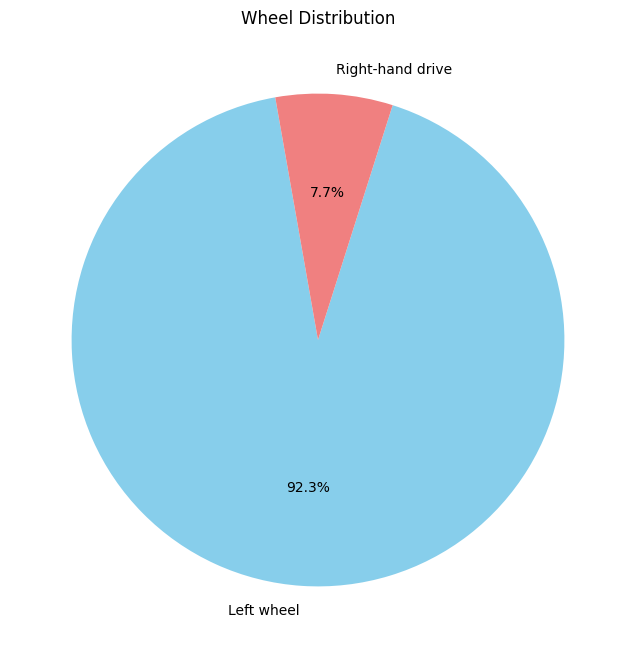

In [41]:
print("Wheel Frequency Distribution:")
wheel_counts = data['Wheel'].value_counts()
print(wheel_counts)
print("\n")

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(wheel_counts, labels=wheel_counts.index, autopct='%1.1f%%', 
        colors=['skyblue', 'lightcoral'], startangle=100)

# Add title
plt.title("Wheel Distribution")

# Show the plot
plt.show()


**Frequency Distribution of Color**

Color Frequency Distribution:
Color
Black            4944
White            4407
Silver           3729
Grey             2343
Blue             1376
Red               622
Green             321
Orange            252
Brown             185
Carnelian red     177
Golden            143
Beige             134
Sky blue          122
Yellow            105
Purple             39
Pink               25
Name: count, dtype: int64




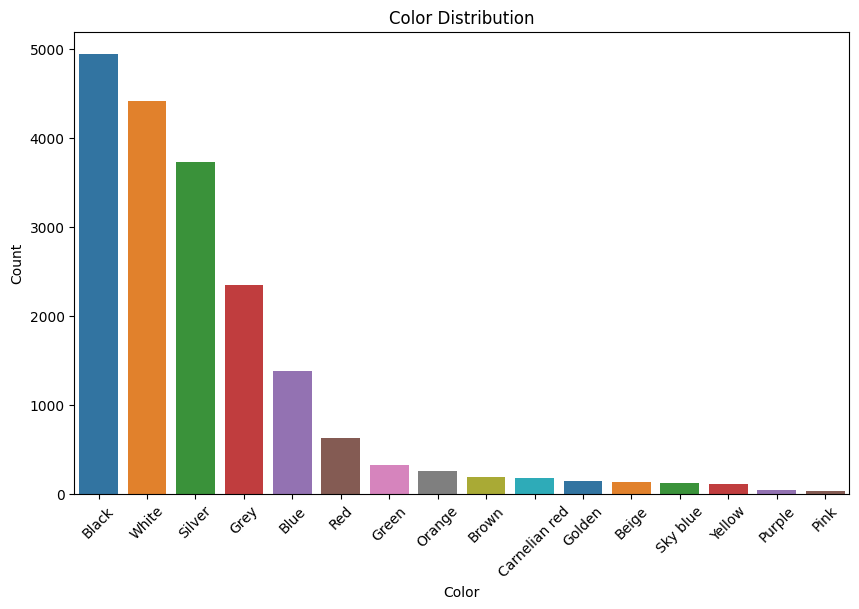

In [42]:
print("Color Frequency Distribution:")
color_counts = data['Color'].value_counts()
print(color_counts)
print("\n")

# Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=color_counts.index, y=color_counts.values, palette="tab10")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add labels and title
plt.xlabel("Color")
plt.ylabel("Count")
plt.title("Color Distribution")

# Show the plot
plt.show()

In [43]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  int64  
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  float64
 9   Mileage           18924 non-null  int64  
 10  Cylinders         18924 non-null  int64  
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  int64  
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

**Chi-Square Test**

In [44]:
# Chi-Square Test for relationships between categorical variables

#List of categorical variables to analyze
categorical_vars = ['Manufacturer', 'Model', 'Category', 'Leather interior', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']
chi_square_results = {}

for i in range(len(categorical_vars)):
    for j in range(i + 1, len(categorical_vars)):
        var1, var2 = categorical_vars[i], categorical_vars[j]
        contingency_table = pd.crosstab(data[var1], data[var2])
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
        chi_square_results[(var1, var2)] = p

# Print Chi-Square Test Results
print("\nChi-Square Test Results (P-Values):")
for pair, p_value in chi_square_results.items():
    print(f"{pair[0]} vs {pair[1]}: P-Value = {p_value:.5f}")

# Interpretation of Chi-Square results
print("\n🔹 Interpretation:")
print("✅ If P-Value < 0.05: The two categorical variables are dependent (have a relationship).")
print("❌ If P-Value ≥ 0.05: The variables are independent.")


Chi-Square Test Results (P-Values):
Manufacturer vs Model: P-Value = 0.00000
Manufacturer vs Category: P-Value = 0.00000
Manufacturer vs Leather interior: P-Value = 0.00000
Manufacturer vs Fuel type: P-Value = 0.00000
Manufacturer vs Gear box type: P-Value = 0.00000
Manufacturer vs Drive wheels: P-Value = 0.00000
Manufacturer vs Wheel: P-Value = 0.00000
Manufacturer vs Color: P-Value = 0.00000
Model vs Category: P-Value = 0.00000
Model vs Leather interior: P-Value = 0.00000
Model vs Fuel type: P-Value = 0.00000
Model vs Gear box type: P-Value = 0.00000
Model vs Drive wheels: P-Value = 0.00000
Model vs Wheel: P-Value = 0.00000
Model vs Color: P-Value = 0.00000
Category vs Leather interior: P-Value = 0.00000
Category vs Fuel type: P-Value = 0.00000
Category vs Gear box type: P-Value = 0.00000
Category vs Drive wheels: P-Value = 0.00000
Category vs Wheel: P-Value = 0.00000
Category vs Color: P-Value = 0.00000
Leather interior vs Fuel type: P-Value = 0.00000
Leather interior vs Gear box t

**Interpreting Of The Results:** All p-values are essentially 0, which means that every pair of variables is highly dependent on each other.

✅ Manufacturer vs Model (p = 0.00000) → The car's model is strongly associated with its manufacturer (which makes sense).

✅ Manufacturer vs Fuel Type (p = 0.00000) → Different manufacturers tend to use specific fuel types (Ford → Petrol/diesel).

✅ Model vs Gear Box Type (p = 0.00000) → A car model often comes with a specific transmission type (sports cars typically have automatic or Tiptronic , Porsche  → Automatic/ Tiptronic).

✅ Fuel Type vs Gear Box Type (p = 0.00000) → Fuel type can influence gearbox type 
(Hybrids → Mostly Automatic or Variator (CVT),
Petrol & Diesel → A mix of Manual and Automatic, and Tiptronic (Sports cars and luxury vehicles favor automatics, while budget cars and older models often have manuals)).

The only p-value that is slightly higher (but still very significant) is:

✅ Drive Wheels vs Wheel (p = 0.00090) → While related, this association might not be as strong as the others.

**Pairwise Relationships (Boxplots & ANOVA)**

In [45]:
# Performs ANOVA to check the relationship between Price and a categorical variable."""

categorical_vars = ['Manufacturer', 'Model', 'Category', 'Leather interior', 
                    'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']

# Create a copy for analysis
data_anova = data.copy()

# Encode categorical variables for ANOVA
label_encoders = {}
for var in categorical_vars:
       le = LabelEncoder()
       data_anova[var] = le.fit_transform(data_anova[var])
       label_encoders[var] = le

# ANOVA calculation
anova_results = {}
for var in categorical_vars:
    groups = [data_anova['Price'][data_anova[var] == category] for category in data_anova[var].unique()]
    anova_results[var] = stats.f_oneway(*groups)

# Print results
print("\nANOVA Test Results (P-Values):")
for var, result in anova_results.items():
    print(f"{var}: P-Value = {result.pvalue:.5f}")

print("\n🔹 Interpretation:")
print("✅ If P-Value < 0.05: The categorical variable significantly influences Price.")
print("❌ If P-Value ≥ 0.05: No strong effect of the variable on Price.")



ANOVA Test Results (P-Values):
Manufacturer: P-Value = 0.31196
Model: P-Value = 1.00000
Category: P-Value = 0.00000
Leather interior: P-Value = 0.93959
Fuel type: P-Value = 0.00050
Gear box type: P-Value = 0.01624
Drive wheels: P-Value = 0.90164
Wheel: P-Value = 0.04521
Color: P-Value = 0.68867

🔹 Interpretation:
✅ If P-Value < 0.05: The categorical variable significantly influences Price.
❌ If P-Value ≥ 0.05: No strong effect of the variable on Price.


**Interpreting Of The Results:**

❌ Manufacturer (P-Value = 0.31196) and Model (P-Value = 1.00000) have no significant effect → This suggests that other factors (Category, Fuel Type) explain price better. Maybe within each brand, models have a wide range of prices, reducing the brand’s direct influence.

❌ Leather Interior and Color don’t affect price → People might pay extra for features, but these alone don't strongly determine price.

✅ Category (SUV, Sedan, etc.) → Strongest effect on price, as expected (luxury vs. economy cars).

✅ Fuel Type (Hybrid, Diesel, Petrol, etc.) →Fuel type (Petrol, Diesel, Hybrid, etc.) affects price, likely because hybrids & diesel cars cost more.

✅ Gearbox Type (Manual, Automatic, etc.) → Transmission type affects price, likely because automatic cars are more expensive than manual ones.

✅ Wheel Type → Weak but noticeable effect,possibly due to premium wheels on high-end models.


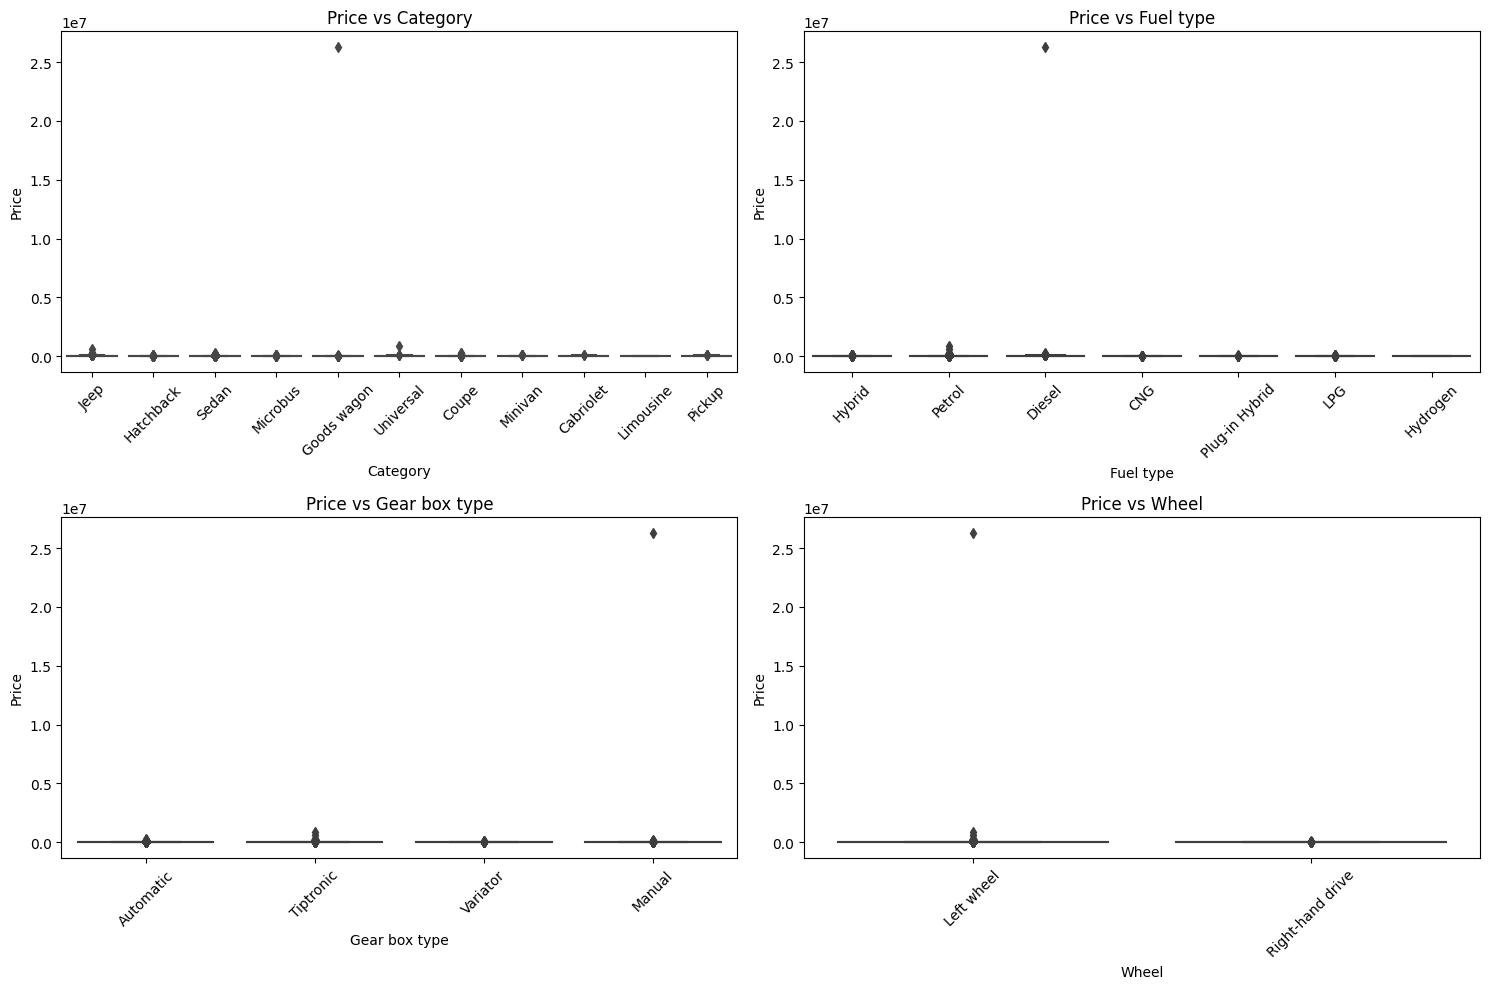

In [46]:
# Visualize significant variables
significant_vars = [var for var, result in anova_results.items() if result.pvalue < 0.05]
num_plots = len(significant_vars)
num_rows = (num_plots + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))

for i, var in enumerate(significant_vars):
    ax = axes.flat[i] if num_plots > 1 else axes
    sns.boxplot(x=data[var], y=data['Price'], ax=ax)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"Price vs {var}")

if num_plots % 2 != 0 and num_plots > 1:
    fig.delaxes(axes.flat[-1])

plt.tight_layout()
plt.show()

In [47]:
data_check.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          18924 non-null  int64  
 1   Levy           18924 non-null  int64  
 2   Engine volume  18924 non-null  float64
 3   Mileage        18924 non-null  int64  
 4   Cylinders      18924 non-null  int64  
 5   Airbags        18924 non-null  int64  
 6   Doors          18924 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 1.2 MB


# Modeling

1️⃣ Converting the categorical variables into numbers using One-Hot Encoding.

2️⃣ Prepared Data for Modeling

3️⃣ Trained The Models & Evaluated the Performance :

✅ Linear Regression, Random Forest Regressor, Decision Tree, XGBoost, KNN MLPRegressor, SVR, Ridge, Lasso.

✔  Used Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score and RMSE to measure accuracy.

4️⃣  Optimize & Improve Performance : 

✔ Finds the best hyperparameters for Random Forest.

5️⃣ Improves accuracy & reduces overfitting.

✔ Gives better price predictions.

6️⃣ Analyze Feature Importance (see which factors affect car price the most)?
🔹 Compare Random Forest vs. Linear Regression results

**1. Convert Categorical Variables Using Label Encoding**

In [48]:
# Categorical and numerical feature selection
categorical_data = data[['Manufacturer', 'Model', 'Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Leather interior','Color']]
numerical_data = data_check[['Price', 'Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags', 'Doors']].copy()

# Label Encoding for categorical features
label_encoders = {}  
for col in categorical_data.columns:
    le = LabelEncoder()
    categorical_data[col] = le.fit_transform(categorical_data[col])
    label_encoders[col] = le  

# Concatenating the encoded categorical data with numerical data
final_dataset = pd.concat([categorical_data, numerical_data], axis=1)

# Display the final dataset
final_dataset

,Manufacturer,Model,Category,Fuel type,Gear box type,Drive wheels,Wheel,Leather interior,Color,Price,Levy,Engine volume,Mileage,Cylinders,Airbags,Doors
0,32,1242,4,2,0,0,0,1,12,13328,1399,3.5,186005,4,12,4
1,8,658,4,5,2,0,0,0,1,16621,1018,3.0,192000,4,8,4
2,21,684,3,5,3,1,1,0,1,8467,0,1.3,200000,4,2,4
3,16,661,4,2,0,0,0,1,14,3607,862,2.5,168966,4,0,4
4,21,684,3,5,0,1,0,1,12,11726,446,1.3,91901,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,36,385,1,0,1,2,0,1,12,8467,0,2.0,300000,4,5,4
19233,23,1334,9,5,2,1,0,1,11,15681,831,2.4,161600,4,8,4
19234,23,1442,4,1,0,1,0,1,7,26108,836,2.0,116365,4,4,4
19235,8,456,4,1,0,1,0,1,1,5331,1288,2.0,51258,4,4,4


In [49]:
final_dataset.dtypes

Manufacturer          int64
Model                 int64
Category              int64
Fuel type             int64
Gear box type         int64
Drive wheels          int64
Wheel                 int64
Leather interior      int64
Color                 int64
Price                 int64
Levy                  int64
Engine volume       float64
Mileage               int64
Cylinders             int64
Airbags               int64
Doors                 int64
dtype: object

**2. Prepare The Data for Modeling**

In [50]:
# Define features (X) and target variable (y)
X = final_dataset.drop('Price', axis=1)  # All features except price
y = final_dataset['Price'] # Target variable (Car Price)


# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features for SVR (and optionally XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**3. Train Models & Evaluate Performance**

In [51]:

# Define models with hyperparameters
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42),
    "SVR": SVR(kernel="rbf", C=10, gamma=0.1),  # Using RBF kernel
    "KNN": KNeighborsRegressor(n_neighbors=5, weights='distance'),
    "MLPRegressor": MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', max_iter=500, random_state=42),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

# Hyperparameter tuning using GridSearchCV
param_grid = {
    "Random Forest": {"n_estimators": [100, 200], "max_depth": [10, 20]},
    "Decision Tree": {"max_depth": [5, 10, 20]},
    "XGBoost": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 6]},
    "SVR": {"C": [1, 10, 100], "gamma": [0.01, 0.1, 1]},
    "KNN": {"n_neighbors": [3, 5, 10], "weights": ["uniform", "distance"]},
    "MLPRegressor": {"hidden_layer_sizes": [(64, 32), (128, 64)], "activation": ["relu", "tanh"], "solver": ["adam", "sgd"]}
}

# Store results
results = []

# Define function to train and evaluate models
def predict_and_evaluate(model, model_name, use_scaled=False):
    """Train, predict, and evaluate the model with R², RMSE, and score."""
    X_train_data = X_train_scaled if use_scaled else X_train
    X_test_data = X_test_scaled if use_scaled else X_test

    model.fit(X_train_data, y_train)
    y_pred = model.predict(X_test_data)

    # Compute Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    score = model.score(X_test_data, y_test)

    # Print Model Score
    print(f"✅ Model: {model_name} | Score: {score:.4f} | R²: {r2:.4f} | RMSE: {rmse:.2f}| MAE: {mae:.2f}| MSE: {mse:.2f}")

    # Store results
    results.append({"Model": model_name, "R² Score": r2, "RMSE": rmse, "MAE": mae, "MSE": mse})

# Train each model and evaluate performance
for name, model in models.items():
    if name in param_grid:  # Apply hyperparameter tuning
        grid_search = GridSearchCV(model, param_grid[name], scoring='r2', cv=3, n_jobs=-1)
        grid_search.fit(X_train_scaled if name in ["SVR", "KNN", "MLPRegressor"] else X_train, y_train)
        best_model = grid_search.best_estimator_
    else:  # No tuning needed
        best_model = model

    # Use scaled data for SVR, KNN, MLPRegressor
    use_scaled = name in ["SVR", "KNN", "MLPRegressor"]
    predict_and_evaluate(best_model, name, use_scaled=use_scaled)

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display results
print("\n🔹 Model Performance Comparison:")
print(results_df)

✅ Model: Linear Regression | Score: 0.0845 | R²: 0.0845 | RMSE: 10554.97| MAE: 8330.01| MSE: 111407367.53
✅ Model: Random Forest | Score: 0.6293 | R²: 0.6293 | RMSE: 6716.01| MAE: 4221.40| MSE: 45104810.85
✅ Model: Decision Tree | Score: 0.4544 | R²: 0.4544 | RMSE: 8148.02| MAE: 5568.31| MSE: 66390267.13
✅ Model: XGBoost | Score: 0.6024 | R²: 0.6024 | RMSE: 6955.42| MAE: 4781.45| MSE: 48377848.67
✅ Model: SVR | Score: 0.2141 | R²: 0.2141 | RMSE: 9779.23| MAE: 7009.75| MSE: 95633328.84
✅ Model: KNN | Score: 0.5602 | R²: 0.5602 | RMSE: 7315.16| MAE: 4550.14| MSE: 53511575.36
✅ Model: MLPRegressor | Score: 0.4458 | R²: 0.4458 | RMSE: 8211.83| MAE: 5996.69| MSE: 67434181.46
✅ Model: Ridge Regression | Score: 0.0845 | R²: 0.0845 | RMSE: 10554.96| MAE: 8329.95| MSE: 111407102.57
✅ Model: Lasso Regression | Score: 0.0845 | R²: 0.0845 | RMSE: 10554.96| MAE: 8329.98| MSE: 111407099.45

🔹 Model Performance Comparison:
               Model  R² Score          RMSE          MAE           MSE
0  Lin

📊 **Analysis of Model Performance Results:**

1️⃣ 🎯 Best Model: **Random Forest** (Highest R², Lowest RMSE) 

✅ R² Score = 0.6293 → Explains 62.93% of the variance in car prices, the highest among all models.

✅ RMSE = 6,716 → Lowest error, meaning predictions are relatively accurate.

I will Try tuning hyperparameters (n_estimators, max_depth, etc.) further to improve performance.

2️⃣ XGBoost Performed Well (🔥 Almost as good as Random Forest) 

✅ R² Score = 0.6024 → Explains 60.24% of the variance.

✅ RMSE = 6,955 → Only slightly higher error than Random Forest.

3️⃣ KNN Performed Better Than Expected (👍 Surprisingly good performance)

✅ R² Score = 0.5602 → Better than Decision Tree, worse than RF/XGBoost.

✅ RMSE = 7,315 → Error is lower than Decision Tree.

4️⃣ Decision Tree Performed Decently but Not as Well as RF/XGBoost

✅ R² Score = 0.4544 → Explains 45.44% of variance, better than linear models but worse than RF/XGBoost.

✅ RMSE = 8,148 → Higher error than RF/XGBoost but still reasonable.

5️⃣ Neural Network (MLPRegressor) Performed Worse Than Expected

✅ R² Score = 0.4458 → Slightly worse than Decision Tree and KNN.

✅ RMSE = 8,211 → Not competitive with RF/XGBoost.

6️⃣ Linear Regression, Ridge, and Lasso Performed Poorly : 

✅ R² Score = 0.0845 → Very low, meaning the model explains only 8.45% of the variance in car prices.



**Plot R² Score & RMSE**

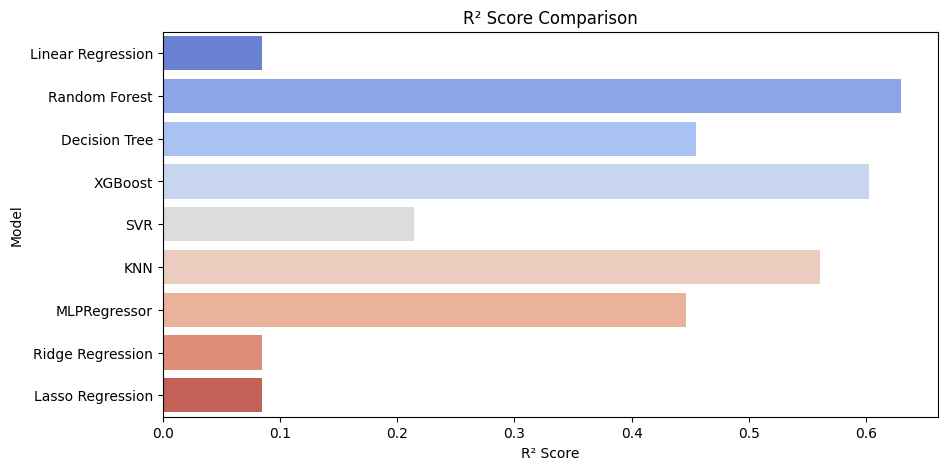

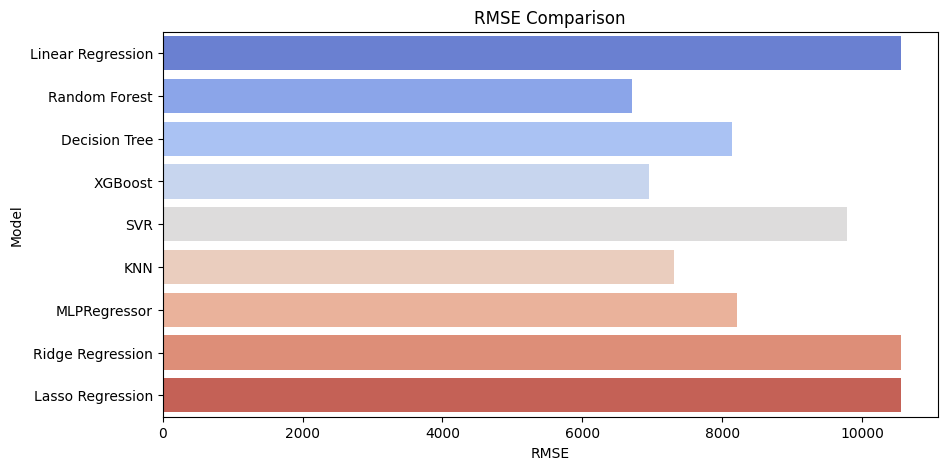

In [52]:
# Plot R² Score
plt.figure(figsize=(10, 5))
sns.barplot(x="R² Score", y="Model", data=results_df, palette="coolwarm")
plt.title("R² Score Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.show()

# Plot RMSE
plt.figure(figsize=(10, 5))
sns.barplot(x="RMSE", y="Model", data=results_df, palette="coolwarm")
plt.title("RMSE Comparison")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

**5. Optimize & Improve Performance (Random Forest Hyperparameter Tuning):**

In [53]:
# Define the parameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"],
}

# Initialize the model
rf = RandomForestRegressor(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Print best parameters
print("\n🔹 Best Parameters for Random Forest:", grid_search.best_params_)

# Train final model with best parameters
rf_best = RandomForestRegressor(**grid_search.best_params_, random_state=42)
rf_best.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf_best = rf_best.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf_best)
mse_rf = mean_squared_error(y_test, y_pred_rf_best)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf_best)

print("\n🔹 Optimized Random Forest Performance:")
print(f"MAE: {mae_rf}, MSE: {mse_rf}, RMSE: {rmse_rf}, R² Score: {r2_rf}")

Fitting 3 folds for each of 324 candidates, totalling 972 fits

🔹 Best Parameters for Random Forest: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

🔹 Optimized Random Forest Performance:
MAE: 4125.577884590288, MSE: 43323108.55422601, RMSE: 6582.0292125017195, R² Score: 0.6439749640190003


**6. Analyze Feature Importance & Compare Results:**

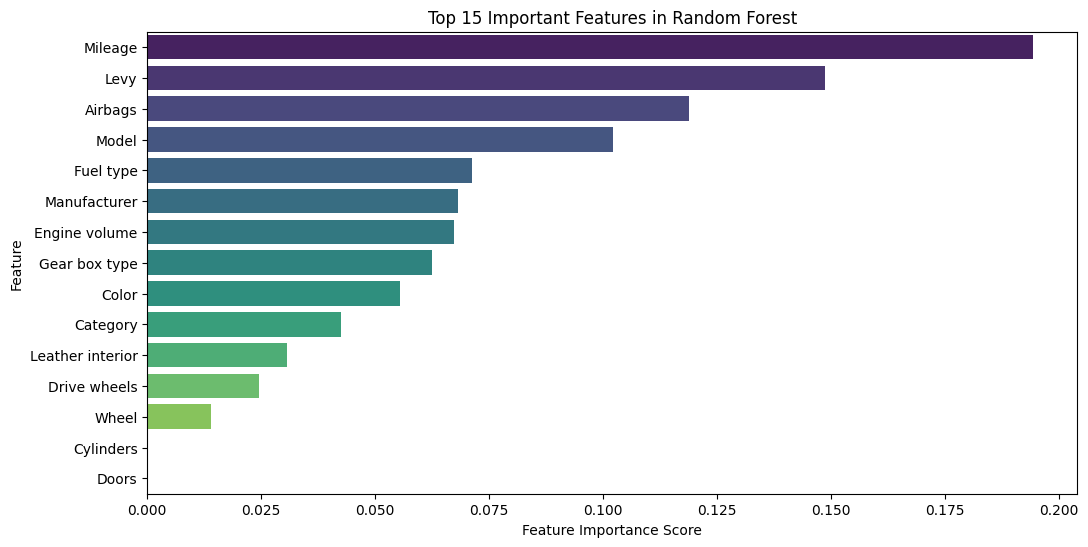

In [54]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": rf_best.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance[:15], palette="viridis")
plt.title("Top 15 Important Features in Random Forest")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.show()
